<a href="https://colab.research.google.com/github/douniaedben/Data-Analysis/blob/main/Lab7_netflix_titles_dataset_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# **Initial Exploration:**

In [ ]:

netflix_data = pd.read_csv('/content/drive/MyDrive/DA_abs/netflix_titles.csv', encoding='latin1')
DATA= netflix_data.copy()
netflix_data.sample(10)
netflix_data.shape

(8807, 12)

In [ ]:
netflix_data.sample(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
832,s833,TV Show,Word of Honor,Gary Sing,"Zhang Zhehan, Gong Jun, Zhou Ye, Asher Ma, Sun...",NaN,"May 28, 2021",2021,TV-14,1 Season,"International TV Shows, TV Action & Adventure,...",A disillusioned royal magistrate sets out for ...
8745,s8746,Movie,Willy Wonka & the Chocolate Factory,Mel Stuart,"Gene Wilder, Jack Albertson, Peter Ostrum, Roy...","United States, East Germany, West Germany","January 1, 2020",1971,G,100 min,"Children & Family Movies, Classic Movies, Come...",Zany Willy Wonka causes a stir when he announc...
4647,s4648,TV Show,Daniel Sloss: Live Shows,NaN,Daniel Sloss,United States,"September 11, 2018",2018,TV-MA,1 Season,"Stand-Up Comedy & Talk Shows, TV Comedies",Comedian Daniel Sloss is ready to find the fun...
7850,s7851,TV Show,Reggie Yates Outside Man,NaN,Reggie Yates,United Kingdom,"December 15, 2017",2017,TV-MA,2 Seasons,"British TV Shows, Docuseries, International TV...",Award-winning filmmaker Reggie Yates travels a...
2397,s2398,Movie,Jo Koy: In His Elements,Michael McKay,"Jo Koy, Andrew Lopez, Joey Guila, Andrew Orolfo",United States,"June 12, 2020",2020,TV-MA,55 min,Stand-Up Comedy,"Jo Koy brings the laughs and beats to Manila, ..."
5335,s5336,Movie,Baahubali 2: The Conclusion (Malayalam Version),S.S. Rajamouli,"Prabhas, Rana Daggubati, Anushka Shetty, Taman...",NaN,"August 7, 2017",2017,TV-14,166 min,"Action & Adventure, Dramas, International Movies","To avenge his father's death, a young man lead..."
2983,s2984,TV Show,Night on Earth,NaN,Samira Wiley,United Kingdom,"January 29, 2020",2020,TV-PG,1 Season,"Docuseries, Science & Nature TV",This nature seriesâ new technology lifts nig...
2547,s2548,Movie,Have a Good Trip: Adventures in Psychedelics,Donick Cary,"Nick Offerman, Adam Scott",United States,"May 11, 2020",2020,TV-MA,86 min,Documentaries,Explore hallucinogenic highs and lows as celeb...
3211,s3212,Movie,Kalushi: The Story of Solomon Mahlangu,Mandla Dube,"Thabo Rametsi, Thabo Malema, Welile Nzuza, Jaf...",South Africa,"November 29, 2019",2016,TV-MA,107 min,"Dramas, International Movies",The life and times of iconic South African lib...
4652,s4653,TV Show,Transformers: Robots in Disguise,NaN,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,"September 8, 2018",2016,TV-Y7,1 Season,Kids' TV,When a prison ship crash unleashes hundreds of...


In [ ]:
netflix_data.info() #informations about clumns,missig values and type

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


# my  evaluation of the types of each column:


* **date_added:** is an object, it could be converted to datetime for better analysis   
* **Processed duration** to extract numeric values for analysis {i will add a new clumn named : **process_duration**)








In [ ]:
netflix_data.describe()#statistics


,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [ ]:
netflix_data.isnull().sum() #messing values

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [ ]:
duplicate_rows=netflix_data.duplicated().sum() #check for duplicated values
print("Duplicate Rows:", duplicate_rows)

Duplicate Rows: 0


---> **No duplicate rows  in the dataset**

# **Cleaning The Dataset:**


1. **Handling Missing Values**:

*  Using **fillna()** to replace missing values with a placeholder.

*  Using **.dropna()** to remove rows with missing duration values.








In [ ]:
#replace the NULL"missign" values withe a placeholder:
netflix_data['director'].fillna('Unknown', inplace=True)
netflix_data['cast'].fillna('Unknown', inplace=True)
netflix_data['country'].fillna('Unknown', inplace=True)
netflix_data['rating'].fillna('Not Rated', inplace=True)
netflix_data['date_added'].fillna('Not Added', inplace=True)
#drop the missign values in duration
netflix_data.dropna(subset=['duration'], inplace=True)

cleaned_missing_values = netflix_data.isnull().sum()
print("Missing Values After Cleaning:\n", cleaned_missing_values)
netflix_data.info()



Missing Values After Cleaning:
 show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 8804 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8804 non-null   object
 1   type          8804 non-null   object
 2   title         8804 non-null   object
 3   director      8804 non-null   object
 4   cast          8804 non-null   object
 5   country       8804 non-null   object
 6   date_added    8804 non-null   object
 7   release_year  8804 non-null   int64 
 8   rating        8804 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8804 non-null   object
 11  description   8804 non-null   object
dtypes: int64(1), object(11)
memory usage: 894.2+

<ipython-input-12-4554cb708c8c>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  netflix_data['director'].fillna('Unknown', inplace=True)
<ipython-input-12-4554cb708c8c>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

2. **Removing Duplicates:**
* *No duplicate*  






3. **Standardizing Data Formats:**


*   Add a new clomun named : "**processed_duration**"  a cleaned numeric format of a **duration** clumn  for easier analysis.




In [ ]:
#standardization converting columns to lower or upper case
netflix_data["director"] = netflix_data["director"].str.lower()
netflix_data["cast"] = netflix_data["cast"].str.lower()
netflix_data["listed_in"] = netflix_data["listed_in"].str.lower()
netflix_data["country"] = netflix_data["country"].str.title()
netflix_data["rating"] = netflix_data["rating"].str.upper()

netflix_data.head()




,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,kirsten johnson,unknown,United States,"September 25, 2021",2020,PG-13,90 min,documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,unknown,"ama qamata, khosi ngema, gail mabalane, thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"international tv shows, tv dramas, tv mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,julien leclercq,"sami bouajila, tracy gotoas, samuel jouy, nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"crime tv shows, international tv shows, tv act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,unknown,unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"docuseries, reality tv","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,unknown,"mayur more, jitendra kumar, ranjan raj, alam k...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"international tv shows, romantic tv shows, tv ...",In a city of coaching centers known to train I...


In [ ]:
#function to convert the duration clumn into the numerical format
def process_duration(row):

    if "Season" in row:  # Check for seasons
        return int(row.split()[0])
    elif "min" in row:  # Check for minutes
        return int(row.split()[0])
    else:
        return None  # Handle unexpected formats
#add a new clomun :
netflix_data['processed_duration'] = netflix_data['duration'].apply(process_duration)

print(netflix_data[['duration', 'processed_duration']].head())
#duration by type:
movies_duration = netflix_data[netflix_data['type'] == 'Movie']['processed_duration']
tv_shows_seasons = netflix_data[netflix_data['type'] == 'TV Show']['processed_duration']

movies_duration_stats = movies_duration.describe()
tv_shows_seasons_stats = tv_shows_seasons.describe()

movies_duration_stats, tv_shows_seasons_stats


    duration  processed_duration
0     90 min                  90
1  2 Seasons                   2
2   1 Season                   1
3   1 Season                   1
4  2 Seasons                   2


(count    6128.000000
 mean       99.577187
 std        28.290593
 min         3.000000
 25%        87.000000
 50%        98.000000
 75%       114.000000
 max       312.000000
 Name: processed_duration, dtype: float64,
 count    2676.000000
 mean        1.764948
 std         1.582752
 min         1.000000
 25%         1.000000
 50%         1.000000
 75%         2.000000
 max        17.000000
 Name: processed_duration, dtype: float64)

# **Univariate Analysis:**

1.  **Graphical Analysis**:




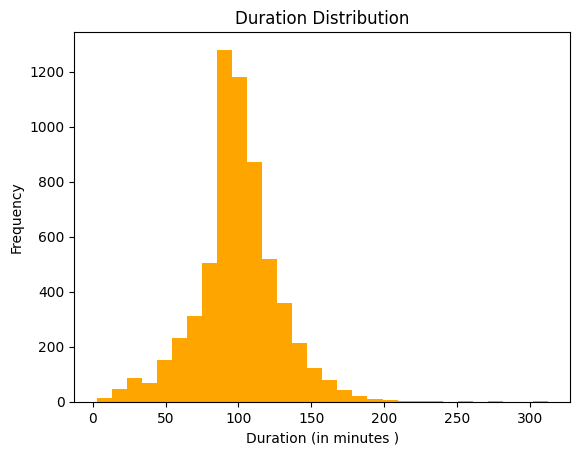

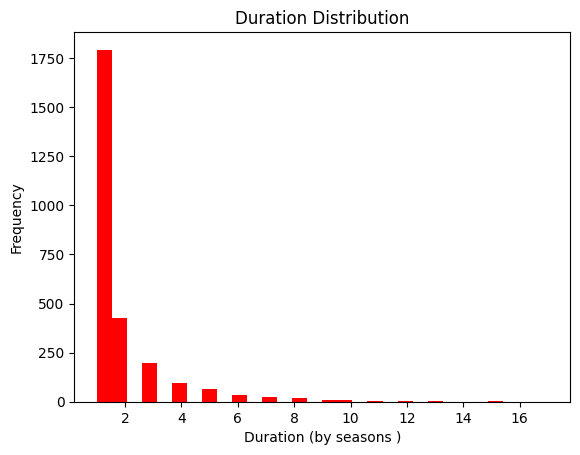

In [ ]:
#histogram for processed duration:
movies_duration = netflix_data[netflix_data['type'] == 'Movie']['processed_duration']
tv_shows_seasons = netflix_data[netflix_data['type'] == 'TV Show']['processed_duration']

#for the movies duration:
movies_duration.plot(kind='hist', bins=30, color='orange', title='Duration Distribution')
plt.xlabel('Duration (in minutes )')
plt.ylabel('Frequency')
plt.show()
#for tv show duration:
tv_shows_seasons.plot(kind='hist', bins=30, color='red', title='Duration Distribution')
plt.xlabel('Duration (by seasons )')
plt.ylabel('Frequency')
plt.show()

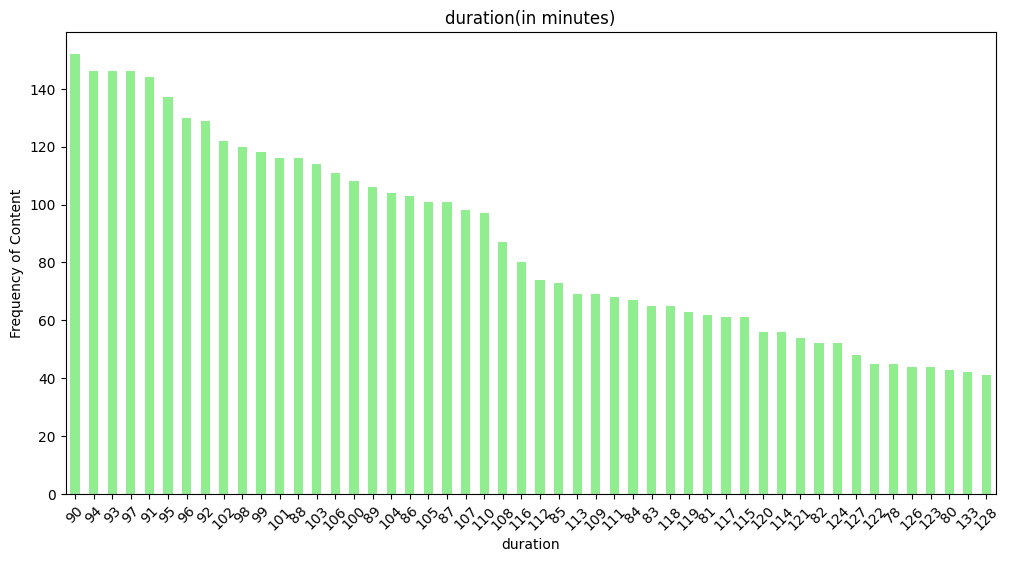

In [ ]:
#pour verifier:
plt.figure(figsize=(12, 6))
movies_duration.value_counts().head(50).plot(kind='bar', color='lightgreen', title='duration(in minutes)')
plt.xlabel('duration')
plt.ylabel('Frequency of Content')
plt.xticks(rotation=45)
plt.show()

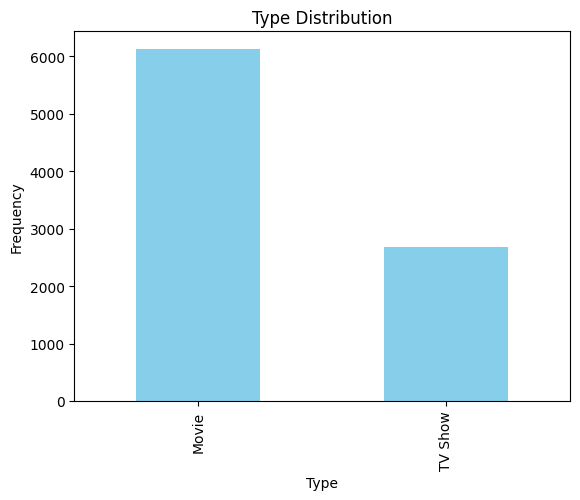

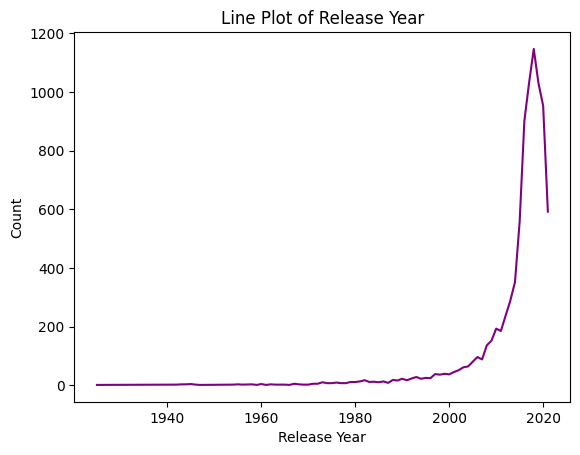

In [ ]:
# Bar chart for categorical variable :
netflix_data['type'].value_counts().plot(kind='bar', color='skyblue', title='Type Distribution')
plt.xlabel('Type')
plt.ylabel('Frequency')
plt.show()


# Line plot for 'release_year'
netflix_data['release_year'].value_counts().sort_index().plot(kind='line', color='purple', title='Line Plot of Release Year')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.show()


2. **non-graphical analysis:**

In [ ]:
print(netflix_data['release_year'].describe())#statistical calculations
 # count the frequency of categorical variables like type and rating:
print(netflix_data['type'].value_counts())
print(netflix_data['rating'].value_counts())

count    8804.000000
mean     2014.180259
std         8.820647
min      1925.000000
25%      2013.000000
50%      2017.000000
75%      2019.000000
max      2021.000000
Name: release_year, dtype: float64
type
Movie      6128
TV Show    2676
Name: count, dtype: int64
rating
TV-MA        3207
TV-14        2160
TV-PG         863
R             799
PG-13         490
TV-Y7         334
TV-Y          307
PG            287
TV-G          220
NR             80
G              41
TV-Y7-FV        6
NOT RATED       4
NC-17           3
UR              3
Name: count, dtype: int64


# **Multivariate Analysis:**
1. **graphical analysis:**

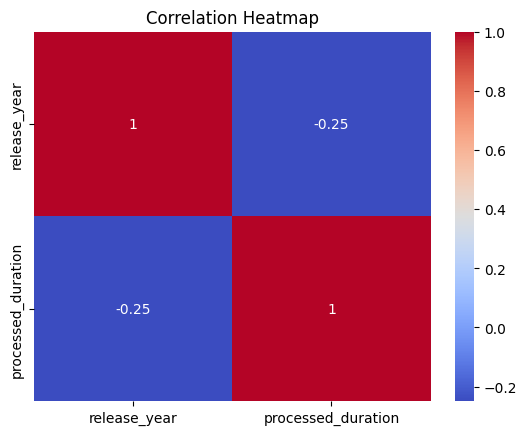

In [ ]:
# Heatmap for correlation between numerical variables
numerical_data = netflix_data[['release_year', 'processed_duration']]
sns.heatmap(numerical_data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


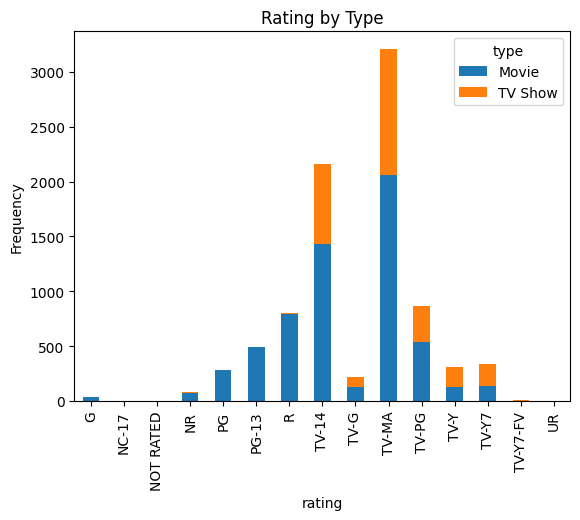

In [ ]:
# Grouped bar chart for categorical variables ( 'rating' vs 'type') by Frequency:
pd.crosstab(netflix_data['rating'], netflix_data['type']).plot(kind='bar', stacked=True)
plt.title('Rating by Type')
plt.ylabel('Frequency')
plt.show()


2.  **Non-Graphical Analysis:**

In [ ]:
# Grouped summary statistics ( average duration by 'rating' and 'country')
grouped_data = netflix_data.groupby(['rating', 'country'])['processed_duration'].mean()
print(grouped_data) #seasens and minutes
print("========================")
#  'Movie' type:
movies_data = netflix_data[netflix_data['type'] == 'Movie']

# Group by 'rating' and 'country', then calculate the mean of 'processed_duration' in minutes
grouped_data = movies_data.groupby(['rating', 'country'])['processed_duration'].mean()

print(grouped_data)





rating    country                                                        
G         Canada                                                              92.0
          Canada, Japan, United States                                        87.0
          France, Switzerland, Spain, United States, United Arab Emirates     84.0
          Germany, United States                                              79.0
          Ireland, United Kingdom, United States                              85.0
                                                                             ...  
TV-Y7-FV  United States, Italy                                                78.0
          Unknown                                                             68.0
UR        France                                                             103.0
          United Kingdom, France                                             103.0
          United States                                                      113.0
Name: process

In [ ]:
pivot_table_data = netflix_data.pivot_table(
    values='processed_duration',  # The value  to summarize
    index=['country'],  # Rows of the pivot table (grouping by country)
    columns=['type', 'rating'],  # Columns of the pivot table (grouping by type and rating)
    aggfunc='mean',  # Aggregation function
    fill_value=0  # Fill missing values with 0 (in our case we don't have a missing values)
)

# Display the pivot table
print(pivot_table_data)


type                                               Movie                  \
rating                                                 G NC-17 NOT RATED   
country                                                                    
, France, Algeria                                    0.0   0.0       0.0   
, South Korea                                        0.0   0.0       0.0   
Argentina                                            0.0   0.0       0.0   
Argentina, Brazil, France, Poland, Germany, Den...   0.0   0.0       0.0   
Argentina, Chile                                     0.0   0.0       0.0   
...                                                  ...   ...       ...   
Venezuela                                            0.0   0.0       0.0   
Venezuela, Colombia                                  0.0   0.0       0.0   
Vietnam                                              0.0   0.0       0.0   
West Germany                                         0.0   0.0       0.0   
Zimbabwe    

# **Bivariate Analysis:**
1. **graphical analysis:**

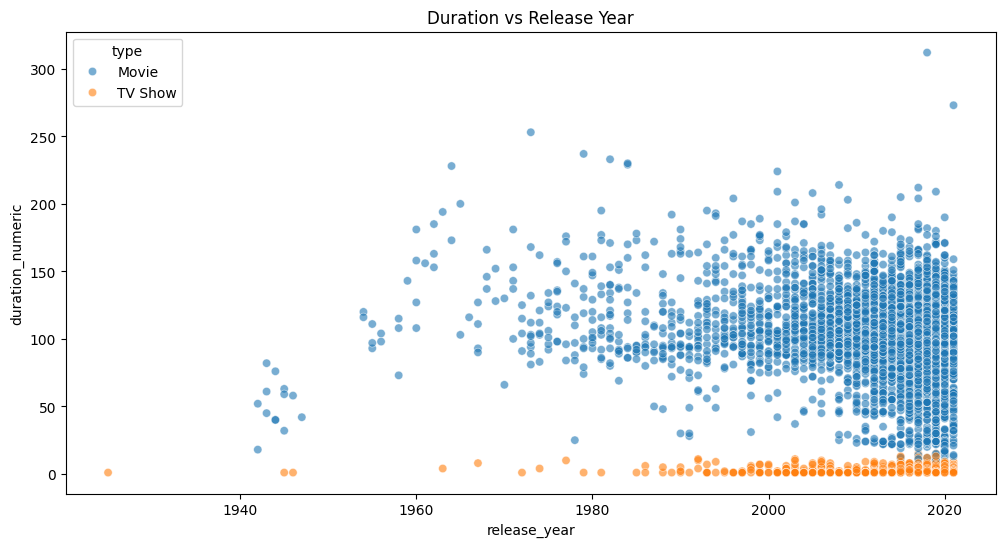

In [ ]:


netflix_data['duration_numeric'] = pd.to_numeric(netflix_data['duration'].str.replace(' min', '').str.replace(' Season', '').str.replace('s', ''), errors='coerce')
plt.figure(figsize=(12, 6))
sns.scatterplot(data=netflix_data, x='release_year', y='duration_numeric', hue='type', alpha=0.6)
plt.title('Duration vs Release Year')
plt.show()


 **Some rows in the "country" column contain multiple countries. Therefore, we will split these entries into a new CSV file to review and ensure the country values are accurate, enabling better analysis:**

In [ ]:
# Split the 'country' column into multiple values based on the delimiter ', '
netdata= netflix_data['country'].str.split(', ')
# Explode the 'country' column into separate rows:
country_data = netdata.explode('country').reset_index(drop=True)
# Save the resulting data to a new CSV file
country_data.to_csv('netflix_country.csv', index=False)




In [ ]:
netdata= pd.read_csv('netflix_country.csv')
netdata.head()
netdata.value_counts()

,count
country,
United States,3686
India,1046
Unknown,831
United Kingdom,804
Canada,445
...,...
Somalia,1
Nicaragua,1
Ethiopia,1


In [ ]:

#Without unknown values:
netdata= netdata[netdata != 'Unknown'].dropna().reset_index(drop=True)
print(netdata.value_counts())


country       
United States     3686
India             1046
United Kingdom     804
Canada             445
France             393
                  ... 
Kazakhstan           1
Jamaica              1
Slovakia             1
Ethiopia             1
Afghanistan          1
Name: count, Length: 126, dtype: int64


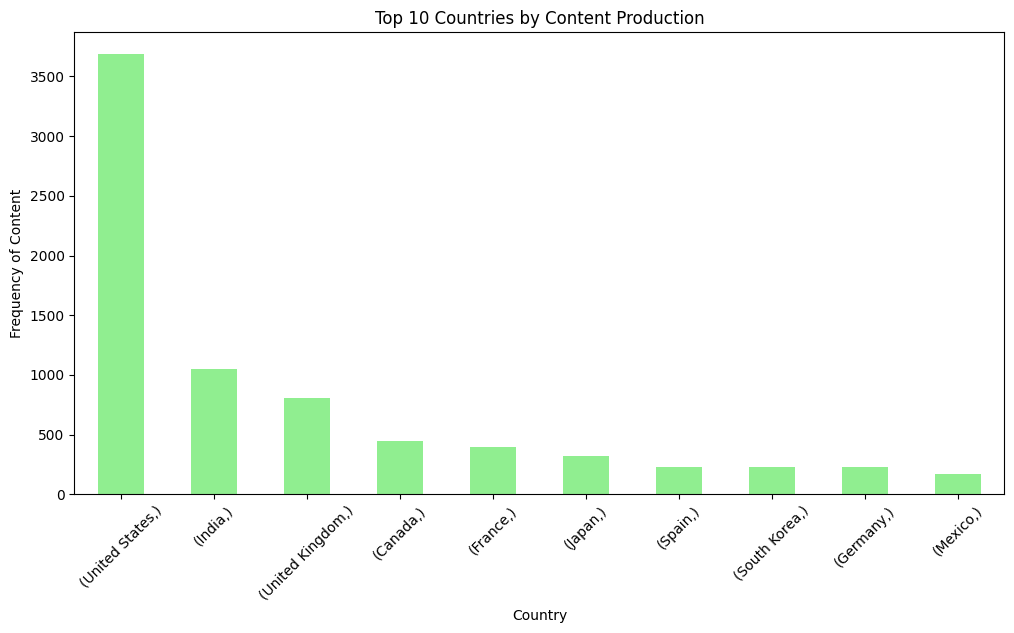

In [ ]:
# Bar plot for Country vs Content (Top 10 countries)
plt.figure(figsize=(12, 6))
netdata.value_counts().head(10).plot(kind='bar', color='lightgreen', title='Top 10 Countries by Content Production')
plt.xlabel('Country')
plt.ylabel('Frequency of Content')
plt.xticks(rotation=45)
plt.show()

**In the original Netflix dataset(some rows contain more than one country per line):**

In [ ]:
netflix_data['country'].value_counts()

,count
country,
United States,2815
India,972
Unknown,831
United Kingdom,419
Japan,245
...,...
"Romania, Bulgaria, Hungary",1
"Uruguay, Guatemala",1
"France, Senegal, Belgium",1


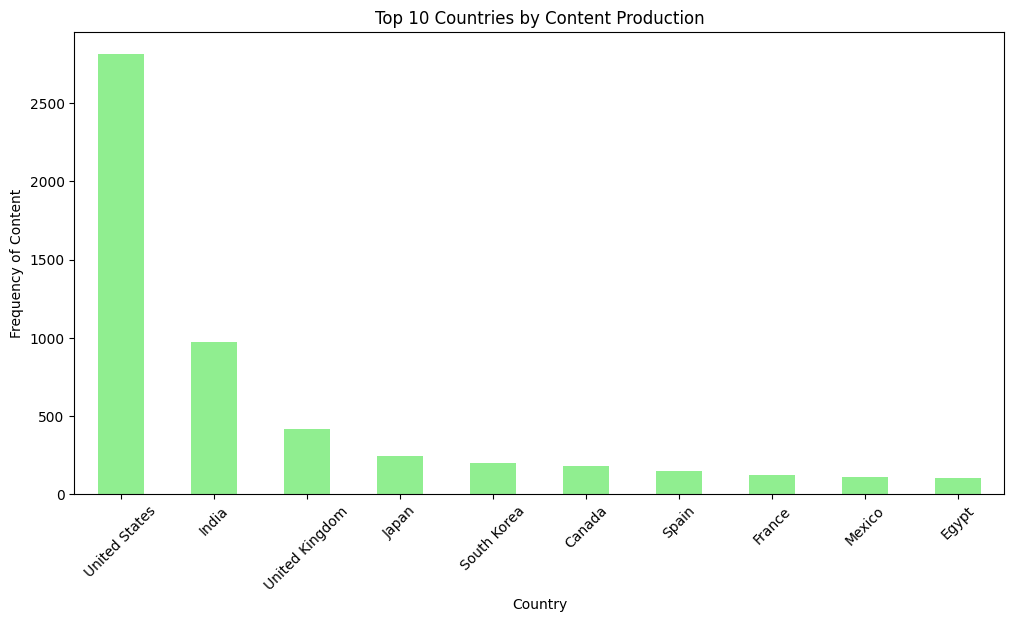

In [ ]:
# Bar plot for Country vs Content (Top 10 countries){in the original netflix dataset}:
dattaa=netflix_data[netflix_data['country']!='Unknown']
plt.figure(figsize=(12, 6))
dattaa['country'].value_counts().head(10).plot(kind='bar', color='lightgreen', title='Top 10 Countries by Content Production')
plt.xlabel('Country')
plt.ylabel('Frequency of Content')
plt.xticks(rotation=45)
plt.show()



2.**Non-Graphical Analysis :**

In [ ]:
# Correlation matrix for numerical variables
correlation_matrix = netflix_data[['release_year', 'processed_duration']].corr()
print(correlation_matrix)


                    release_year  processed_duration
release_year            1.000000           -0.249182
processed_duration     -0.249182            1.000000


In [ ]:
cross_tab = pd.crosstab(netflix_data['rating'],netflix_data['country'])
print(cross_tab)


country    , France, Algeria  , South Korea  Argentina  \
rating                                                   
G                          0              0          0   
NC-17                      0              0          0   
NOT RATED                  0              0          0   
NR                         0              0          2   
PG                         0              0          0   
PG-13                      0              0          0   
R                          0              0          1   
TV-14                      1              0          7   
TV-G                       0              0          2   
TV-MA                      0              1         39   
TV-PG                      0              0          3   
TV-Y                       0              0          2   
TV-Y7                      0              0          0   
TV-Y7-FV                   0              0          0   
UR                         0              0          0   

country    Ar

In [ ]:
#for numirical data:
# Compute the correlation coefficient between 'processed_duration' and 'release_year'
correlation = netflix_data[['processed_duration', 'release_year']].corr()

# Display the correlation matrix
print(correlation)


                    processed_duration  release_year
processed_duration            1.000000     -0.249182
release_year                 -0.249182      1.000000


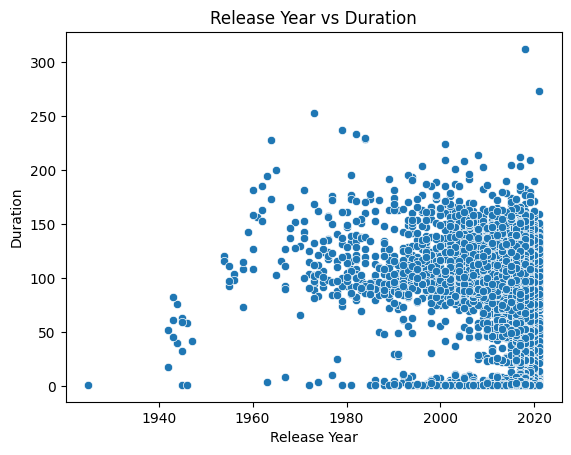

In [ ]:
# Scatter plot for numerical variables
sns.scatterplot(x='release_year', y='processed_duration', data=netflix_data)
plt.title('Release Year vs Duration')
plt.xlabel('Release Year')
plt.ylabel('Duration')
plt.show()

# **save the new cleaned dataset on a csv file:**

In [ ]:
netflix_data.to_csv('/content/drive/MyDrive/DA_abs/cleaning_netflix.csv', index=False, encoding='latin1')
print("Data saved successfully.")

Data saved successfully.
